In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Define the base directory where your folders are located
base_dir = r"C:\Users\Sai charan\Desktop\balanced_augmentation"

# List of folder names (these will be the target labels)
folders = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Prepare lists to hold data
image_paths = []
image_arrays = []
targets = []
image_size = (96, 96)
# Loop through each folder
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    
    # Loop through each image in the folder
    for img_name in os.listdir(folder_path):
        # Get the full image path
        img_path = os.path.join(folder_path, img_name)
        
        # Read the image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Convert the image from BGR (OpenCV default) to RGB (optional, depending on your use case)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, image_size)
        # Append the path, image array, and target label (folder name)
        image_paths.append(img_path)
        image_arrays.append(img_resized)
        targets.append(folder)

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'image_array': image_arrays,
    'target': targets
})

# Display the DataFrame
df.head()


,image_path,image_array,target
0,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
1,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
2,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
3,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
4,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented


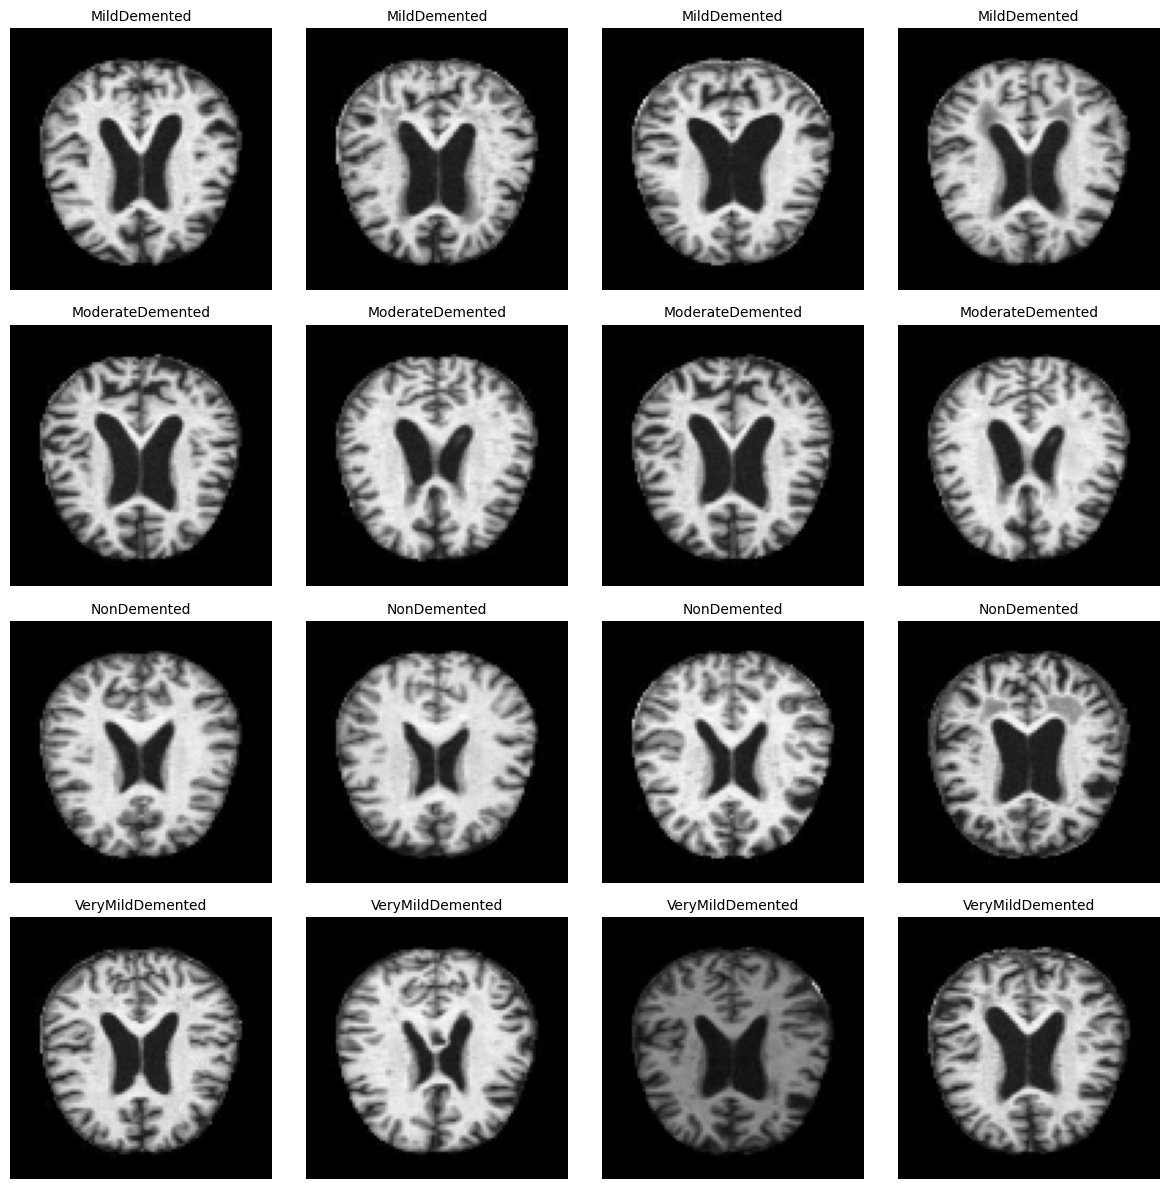

In [3]:
import matplotlib.pyplot as plt

# Number of images to display for each target
num_images = 4

# Set up the plot grid
fig, axs = plt.subplots(len(folders), num_images, figsize=(12, 12))

# Loop through each target (folder name)
for i, folder in enumerate(folders):
    # Get the first 4 images for the current target label
    target_images = df[df['target'] == folder]['image_array'].head(num_images)
    
    # Plot 4 images in the row corresponding to the current target
    for j, img_array in enumerate(target_images):
        # Display the image
        axs[i, j].imshow(img_array)
        axs[i, j].axis('off')  # Hide the axis for a cleaner display
        axs[i, j].set_title(f'{folder}', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [4]:
dict_c = {'MildDemented':0, 'ModerateDemented':1, 'NonDemented':2, 'VeryMildDemented':3}
df['target'] = df['target'].map(dict_c)
df.tail()

,image_path,image_array,target
12795,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
12796,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
12797,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
12798,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
12799,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3


In [5]:
df.head()

,image_path,image_array,target
0,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
1,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
2,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
3,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
4,C:\Users\Sai charan\Desktop\balanced_augmentat...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0


In [6]:
# Convert image arrays and targets to NumPy arrays
X = np.array(df['image_array'].tolist())  # Convert list of arrays to a 4D NumPy array
y = np.array(df.target)       # Labels

# Normalize image data (scale pixel values to 0-1)
X = X / 255.0

In [7]:
np.unique(y)

array([0, 1, 2, 3], dtype=int64)

In [8]:
from tensorflow.keras.utils import to_categorical

# Convert targets to one-hot encoding
y_categorical = to_categorical(y, num_classes=len(dict_c))

In [9]:
y_categorical.shape

(12800, 4)

In [10]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


In [11]:
print(X_train.shape)  # Should print (num_samples, 128, 128, 3)
print(y_train.shape)  # Should print (num_samples, num_classes)


(10240, 96, 96, 3)
(10240, 4)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(96 ,96 , 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(dict_c), activation='softmax')  # Number of output classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 117s 340ms/step - accuracy: 0.4050 - loss: 1.2194 - val_accuracy: 0.5176 - val_loss: 0.9882
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 106s 331ms/step - accuracy: 0.5107 - loss: 0.9992 - val_accuracy: 0.5691 - val_loss: 0.8968
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 105s 329ms/step - accuracy: 0.5637 - loss: 0.9212 - val_accuracy: 0.6434 - val_loss: 0.7899
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 107s 336ms/step - accuracy: 0.6238 - loss: 0.8327 - val_accuracy: 0.6980 - val_loss: 0.6694
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 141s 332ms/step - accuracy: 0.6711 - loss: 0.7244 - val_accuracy: 0.6660 - val_loss: 0.7085
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 106s 330ms/step - accuracy: 0.6891 - loss: 0.6737 - val_accuracy: 0.7301 - val_loss: 0.5671
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 107s 333ms/step - accuracy: 0.7183 - loss: 0.6151 - val_accuracy: 0.7398 - val_loss: 0.5535
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 105s 327ms/step - accuracy: 0.7345 -

In [39]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder


# Create TensorFlow datasets
batch_size = 8  # Use a larger batch size for faster execution

# Load ResNet50 with pre-trained ImageNet weights
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(96, 96, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom layers for classification
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dense(4, activation="softmax")(x)  # Adjust number of classes based on your dataset

# Create the complete model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train the model
hist = model.fit(
    X_train,y_train,
    validation_data=(X_test,y_test),
    epochs=10,
    batch_size=batch_size,
    verbose=1,
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=batch_size)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


Epoch 1/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 501s 377ms/step - accuracy: 0.4059 - loss: 1.2356 - val_accuracy: 0.5254 - val_loss: 1.0356
Epoch 2/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 476s 372ms/step - accuracy: 0.5414 - loss: 1.0041 - val_accuracy: 0.5598 - val_loss: 0.9589
Epoch 3/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 481s 376ms/step - accuracy: 0.5763 - loss: 0.9481 - val_accuracy: 0.5734 - val_loss: 0.9289
Epoch 4/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 482s 376ms/step - accuracy: 0.5888 - loss: 0.8957 - val_accuracy: 0.5980 - val_loss: 0.9066
Epoch 5/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 483s 377ms/step - accuracy: 0.6132 - loss: 0.8641 - val_accuracy: 0.5813 - val_loss: 0.8799
Epoch 6/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 516s 388ms/step - accuracy: 0.6309 - loss: 0.8318 - val_accuracy: 0.6016 - val_loss: 0.8778
Epoch 7/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 486s 380ms/step - accuracy: 0.6303 - loss: 0.8316 - val_accuracy: 0.6195 - val_loss: 0.8611
Epoch 8/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 481s 376ms/step - ac

In [28]:
steps_per_epoch = len(X_train) // batch_size
print(steps_per_epoch)


1280


In [40]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test,y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 56s 643ms/step - accuracy: 0.6192 - loss: 0.8156
Test Loss: 0.8218, Test Accuracy: 0.6164


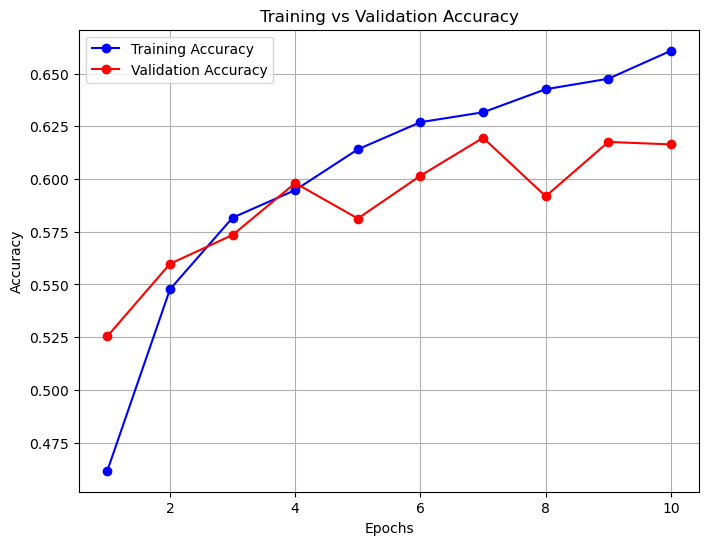

In [43]:
import matplotlib.pyplot as plt

# Assuming `hist` is the history object returned by model.fit()
accuracy = hist.history['accuracy']
val_accuracy = hist.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


80/80 ━━━━━━━━━━━━━━━━━━━━ 65s 764ms/step


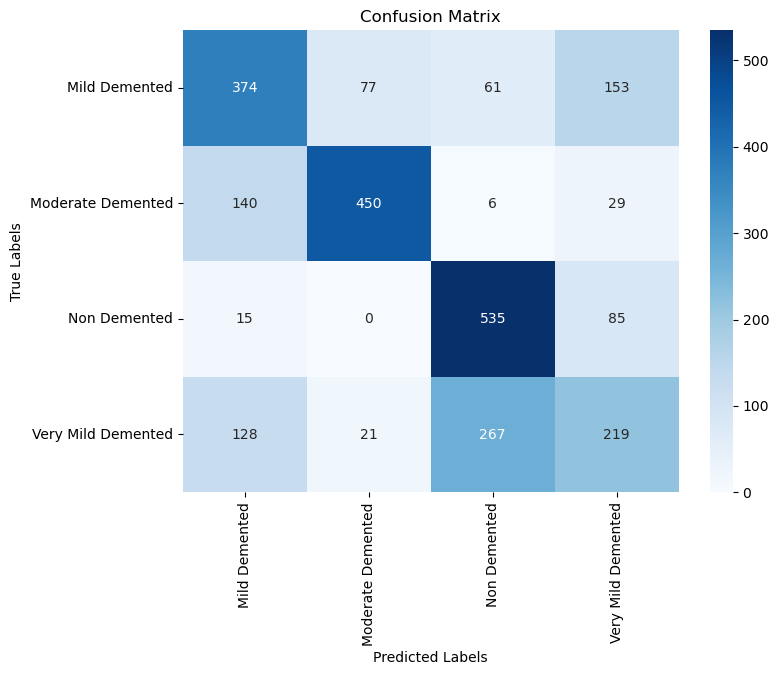

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.57      0.56      0.57       665
 Moderate Demented       0.82      0.72      0.77       625
      Non Demented       0.62      0.84      0.71       635
Very Mild Demented       0.45      0.34      0.39       635

          accuracy                           0.62      2560
         macro avg       0.61      0.62      0.61      2560
      weighted avg       0.61      0.62      0.61      2560



In [41]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]


# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


In [ ]:
import tensorflow as tf

# Resize images to (96, 96, 3)
X_train = tf.image.resize(X_train, (96, 96)).numpy()
X_test = tf.image.resize(X_test, (96, 96)).numpy()


In [ ]:
# Evaluate the model
results = model.evaluate(X_test_resized, y_test, batch_size=32)
print(f"Test Accuracy: {results[1]}")

In [26]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

# Create TensorFlow datasets
batch_size = 8  # Use a larger batch size for faster execution

# Load InceptionV3 with pre-trained ImageNet weights
base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(96, 96, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom layers for classification
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Use Global Average Pooling instead of Flatten
x = Dense(256, activation="relu")(x)
x = Dense(4, activation="softmax")(x)  # Adjust number of classes based on your dataset

# Create the complete model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train the model
hist = model.fit(
    X_train, y_train,  # Ensure X_train and y_train are properly preprocessed
    validation_data=(X_test, y_test),
    epochs=10,  # Adjust epochs if needed
    batch_size=batch_size,
    verbose=1,
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


Epoch 1/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 404s 299ms/step - accuracy: 0.4638 - loss: 1.1815 - val_accuracy: 0.5445 - val_loss: 1.0378
Epoch 2/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 361s 282ms/step - accuracy: 0.6179 - loss: 0.8717 - val_accuracy: 0.6070 - val_loss: 0.9445
Epoch 3/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 234s 183ms/step - accuracy: 0.6515 - loss: 0.8007 - val_accuracy: 0.6465 - val_loss: 0.7902
Epoch 4/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 244s 191ms/step - accuracy: 0.6721 - loss: 0.7416 - val_accuracy: 0.6797 - val_loss: 0.7535
Epoch 5/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 248s 193ms/step - accuracy: 0.6917 - loss: 0.7005 - val_accuracy: 0.6680 - val_loss: 0.7566
Epoch 6/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 252s 185ms/step - accuracy: 0.7296 - loss: 0.6373 - val_accuracy: 0.6793 - val_loss: 0.7387
Epoch 7/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 225s 176ms/step - accuracy: 0.7479 - loss: 0.5965 - val_accuracy: 0.6938 - val_loss: 0.7103
Epoch 8/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 220s 172ms/step - ac

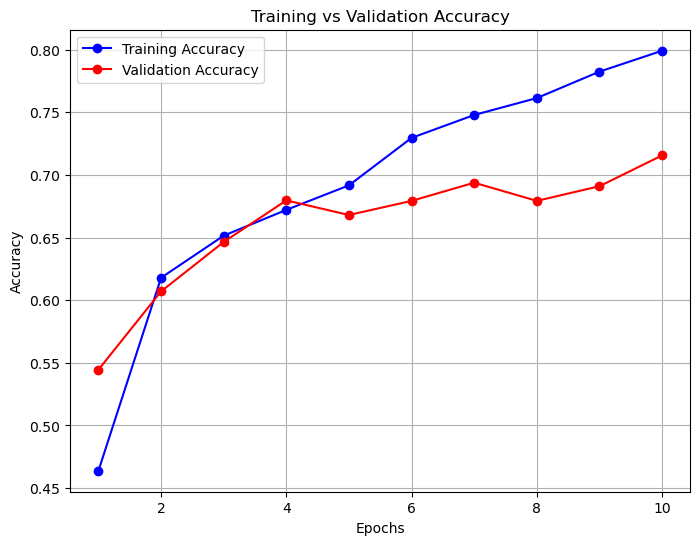

In [38]:
import matplotlib.pyplot as plt

# Data from logs
epochs = list(range(1, 11))
accuracy = [0.4638, 0.6179, 0.6515, 0.6721, 0.6917, 0.7296, 0.7479, 0.7614, 0.7825, 0.7992]
val_accuracy = [0.5445, 0.6070, 0.6465, 0.6797, 0.6680, 0.6793, 0.6938, 0.6793, 0.6910, 0.7156]

# Plotting the training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, accuracy, label='Training Accuracy', marker='o', color='b')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o', color='r')

# Adding titles and labels
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 284ms/step


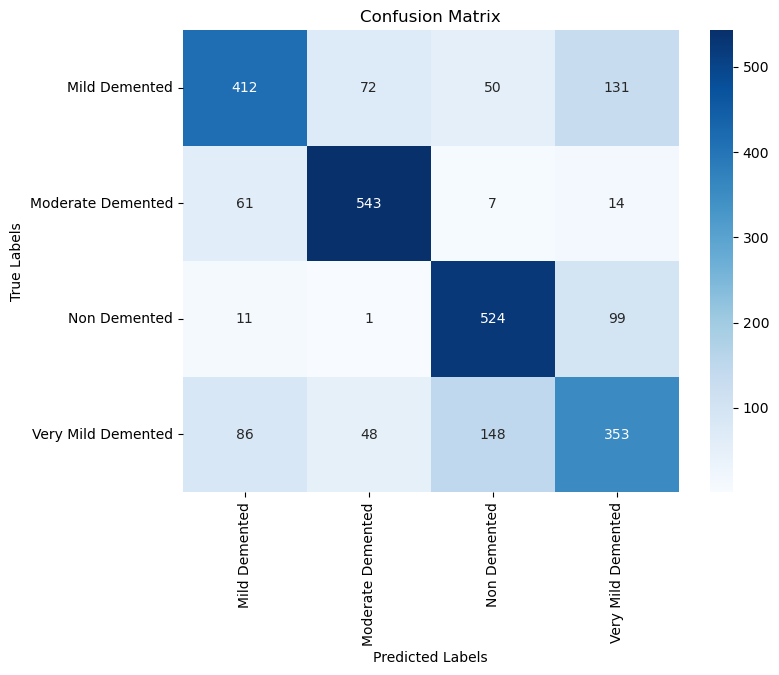

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.72      0.62      0.67       665
 Moderate Demented       0.82      0.87      0.84       625
      Non Demented       0.72      0.83      0.77       635
Very Mild Demented       0.59      0.56      0.57       635

          accuracy                           0.72      2560
         macro avg       0.71      0.72      0.71      2560
      weighted avg       0.71      0.72      0.71      2560



In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test)  # X_test is of shape (num_samples, 128, 128, 3)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


In [31]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define input shape (make sure it matches your image size)
input_shape = (96, 96, 3)  # 96x96 image size, 3 channels (RGB)

# Load VGG16 with pre-trained ImageNet weights, excluding the top layer (fully connected layers)
base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)

# Freeze the convolutional layers of VGG16
base_model.trainable = False

# Add custom layers for your specific classification task
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dense(4, activation="softmax")(x)  # 4 classes for Alzheimer's disease classification

# Create the final model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',  # For multi-class classification
              metrics=['accuracy'])

# Assuming you have prepared X_train, y_train, X_test, y_test
# Use ImageDataGenerator if you need data augmentation for training

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=10, batch_size=8, verbose=1)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


Epoch 1/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 317s 246ms/step - accuracy: 0.4915 - loss: 1.1025 - val_accuracy: 0.6523 - val_loss: 0.8217
Epoch 2/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 329s 257ms/step - accuracy: 0.6798 - loss: 0.7666 - val_accuracy: 0.6895 - val_loss: 0.7351
Epoch 3/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 343s 268ms/step - accuracy: 0.7148 - loss: 0.6689 - val_accuracy: 0.6820 - val_loss: 0.7217
Epoch 4/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 424s 331ms/step - accuracy: 0.7425 - loss: 0.6093 - val_accuracy: 0.7426 - val_loss: 0.5978
Epoch 5/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 386s 301ms/step - accuracy: 0.7525 - loss: 0.5689 - val_accuracy: 0.7570 - val_loss: 0.5684
Epoch 6/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 371s 290ms/step - accuracy: 0.7789 - loss: 0.5245 - val_accuracy: 0.7766 - val_loss: 0.5432
Epoch 7/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 361s 282ms/step - accuracy: 0.7890 - loss: 0.5019 - val_accuracy: 0.7074 - val_loss: 0.6239
Epoch 8/10
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 345s 270ms/step - ac

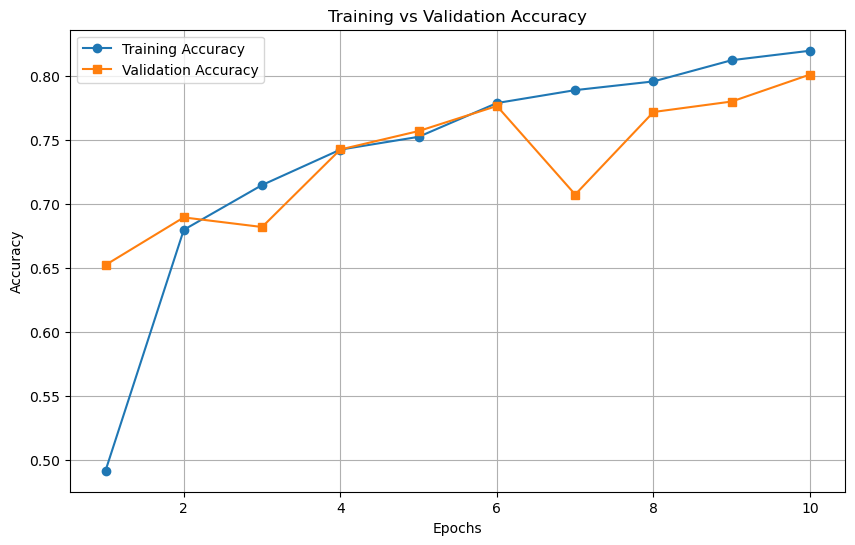

In [35]:
import matplotlib.pyplot as plt

# Extracted accuracy and validation accuracy values
epochs = list(range(1, 11))  # 10 epochs
accuracy = [0.4915, 0.6798, 0.7148, 0.7425, 0.7525, 0.7789, 0.7890, 0.7958, 0.8124, 0.8198]
val_accuracy = [0.6523, 0.6895, 0.6820, 0.7426, 0.7570, 0.7766, 0.7074, 0.7719, 0.7801, 0.8012]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


80/80 ━━━━━━━━━━━━━━━━━━━━ 50s 618ms/step


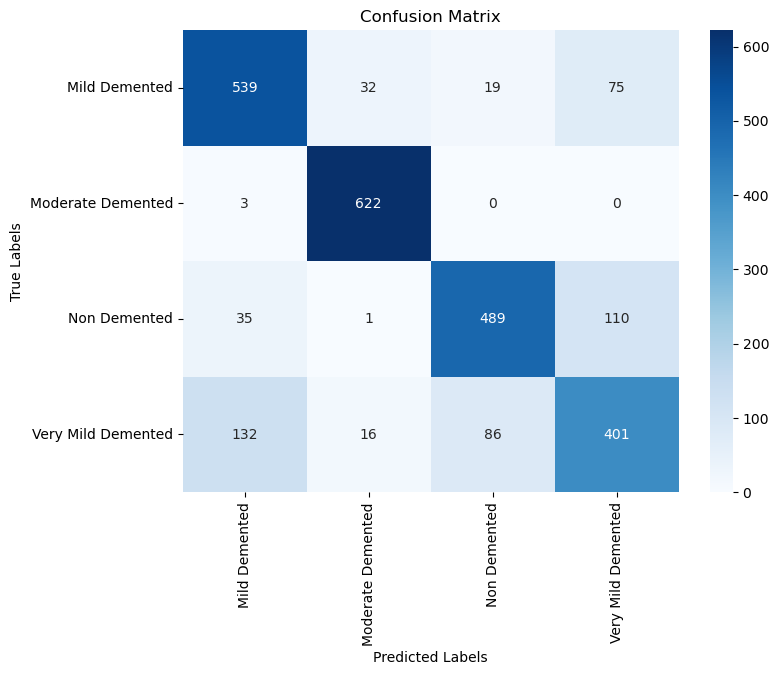

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.76      0.81      0.78       665
 Moderate Demented       0.93      1.00      0.96       625
      Non Demented       0.82      0.77      0.80       635
Very Mild Demented       0.68      0.63      0.66       635

          accuracy                           0.80      2560
         macro avg       0.80      0.80      0.80      2560
      weighted avg       0.80      0.80      0.80      2560



In [32]:
# Predict on the test set
y_pred = model.predict(X_test)  # X_test is of shape (num_samples, 128, 128, 3)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

In [47]:
import cv2
import numpy as np

# Resize function using OpenCV
def resize_images_opencv(images, target_size=(128, 128)):
    resized_images = []
    for image in images:
        resized_image = cv2.resize(image, target_size)
        resized_images.append(resized_image)
    return np.array(resized_images)

# Resize X_train (shape: 10240, 96, 96, 3)
X_train_resized = resize_images_opencv(X_train)
X_test_resized = resize_images_opencv(X_test)

# Verify the new shape
print(X_train_resized.shape)  # Should print (10240, 128, 128, 3)
print(X_test_resized.shape)


(10240, 128, 128, 3)
(2560, 128, 128, 3)


In [59]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(folders), activation='softmax')  # Output layer with the number of classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,  # Adjust epochs based on your dataset size and requirements
    batch_size=32,  # Adjust batch size based on your system's memory
    validation_data=(X_test, y_test)
)

# Evaluate the model on validation data
val_loss, val_accuracy = model.evaluate(X_test, y_test)
print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_121 (Conv2D)                  │ (None, 94, 94, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_122 (Conv2D)                  │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_123 (Conv2D)                  │ (None, 20, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_17 (Flatten)                 │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │       1,638,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 104s 306ms/step - accuracy: 0.4296 - loss: 1.1655 - val_accuracy: 0.5652 - val_loss: 0.9182
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 95s 298ms/step - accuracy: 0.5792 - loss: 0.8863 - val_accuracy: 0.7016 - val_loss: 0.6776
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 93s 291ms/step - accuracy: 0.7015 - loss: 0.6710 - val_accuracy: 0.7504 - val_loss: 0.5711
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 98s 306ms/step - accuracy: 0.7500 - loss: 0.5486 - val_accuracy: 0.7820 - val_loss: 0.4797
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 99s 310ms/step - accuracy: 0.8040 - loss: 0.4520 - val_accuracy: 0.8172 - val_loss: 0.4239
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 104s 326ms/step - accuracy: 0.8375 - loss: 0.3729 - val_accuracy: 0.8527 - val_loss: 0.3592
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 107s 333ms/step - accuracy: 0.8686 - loss: 0.3134 - val_accuracy: 0.8621 - val_loss: 0.3315
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 105s 326ms/step - accuracy: 0.8868 - los

80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step


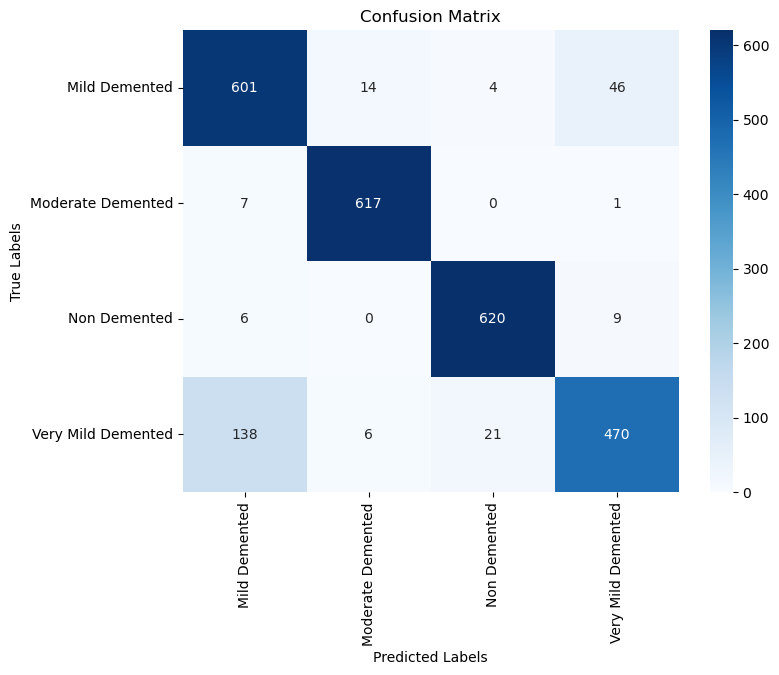

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.80      0.90      0.85       665
 Moderate Demented       0.97      0.99      0.98       625
      Non Demented       0.96      0.98      0.97       635
Very Mild Demented       0.89      0.74      0.81       635

          accuracy                           0.90      2560
         macro avg       0.91      0.90      0.90      2560
      weighted avg       0.90      0.90      0.90      2560



In [60]:
# Predict on the test set
y_pred = model.predict(X_test)  # X_test is of shape (num_samples, 128, 128, 3)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

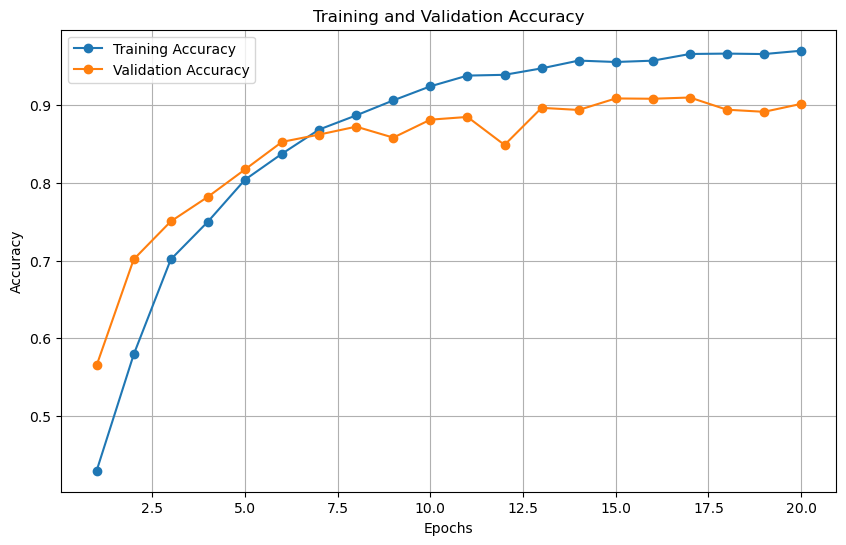

In [62]:
import matplotlib.pyplot as plt

# Accuracy and loss values from training
epochs = list(range(1, 21))
train_accuracy = [0.4296, 0.5792, 0.7015, 0.7500, 0.8040, 0.8375, 0.8686, 0.8868, 0.9061, 0.9242,
                  0.9380, 0.9390, 0.9473, 0.9573, 0.9555, 0.9572, 0.9658, 0.9663, 0.9657, 0.9700]
val_accuracy = [0.5652, 0.7016, 0.7504, 0.7820, 0.8172, 0.8527, 0.8621, 0.8723, 0.8582, 0.8813,
                0.8848, 0.8488, 0.8965, 0.8938, 0.9086, 0.9082, 0.9098, 0.8941, 0.8914, 0.9016]

# Plot accuracy and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracy, label="Training Accuracy", marker="o")
plt.plot(epochs, val_accuracy, label="Validation Accuracy", marker="o")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
